In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import re
from AgentTorch.substep import SubstepTransition
from AgentTorch.helpers import get_by_path

In [5]:
class KillIMCells(SubstepTransition):
    """
        Transition to kill immune cells in the state
        Update the state of the immune cells depending upon the rules

        Args:
            config (dict): the input state
            input_variables (dict): dictionary of input variables
            output_variables (dict): dictionary of output variables
            arguments (dict): dictionary of arguments

        Returns:
            state (dict): the output state
        
        Parameters:
            IMprolmax (float): maximum capacity of proliferation for immune cells
            IMkmax (float): maximum killing capacity of immune cells
            IMpprol (float): probability of proliferation of immune cells
            IMpdeath (float): probability of death of immune cells
            CD8_proliferation_status (int): status of CD8 cells
            CD8_non_proliferation_status (int): status of CD8 cells
            CD8_engagement_status (int): status of CD8 cells
        
        Steps:
            1. Feed the input state to the transition function
            2. Get the input variables (target immune cells) from the action substep 
            3. Get the nature of the immune cells
            4. The condition is if the maximum killing capacity of immune cells is less than zero or the 
            maximum proliferation capacity of immune cells is less than zero or the maximum proliferation 
            capacity of immune cells is greater than maximum or the nature of the immune cells is death.
            5. If the condition is true, then remove those immune cells from the grid and update the state

    """
    def __init__(self, config, input_variables, output_variables, arguments):
        super().__init__(config, input_variables, output_variables, arguments)
    
    def _get_nature(self, IMpdeath, IMpprol):
        random_number = torch.randn(1)
        if random_number < IMpprol:
            nature = "proliferate"
        elif random_number < IMpprol + IMpdeath or random_number > IMpprol:
            nature = "death"
        else:
            nature = "migrate"
        return nature

    def forward(self, state):
        input_variables = self.input_variables

        # Get the input variables
        IMprolmax = get_by_path(state, re.split("/", input_variables["IMprolmax"]))
        IMkmax = get_by_path(state, re.split("/", input_variables["IMkmax"]))
        IMpprol = get_by_path(state, re.split("/", input_variables["IMpprol"]))
        IMpdeath = get_by_path(state, re.split("/", input_variables["IMpdeath"]))
        CD8_proliferation_status = get_by_path(state, re.split("/", input_variables["CD8_proliferation_status"]))
        CD8_non_proliferation_status = get_by_path(state, re.split("/", input_variables["CD8_non_proliferation_status"]))
        CD8_engagement_status = get_by_path(state, re.split("/", input_variables["CD8_engagement_status"]))

        # rules for killing immune cells, remove from the grid and update the state
        if IMkmax < 0 | IMprolmax < 0 | IMprolmax > 10 | self._get_nature(IMpdeath, IMpprol) == 'death':
            immune_cells_id = self.config['agents']['immune_cells']['id']
            state['cell_grid'][immune_cells_id] = torch.zeros_like(state['cell_grid'][immune_cells_id])
            IMkmax[immune_cells_id] = torch.zeros_like(IMkmax[immune_cells_id])
            IMprolmax[immune_cells_id] = torch.zeros_like(IMprolmax[immune_cells_id])
            CD8_proliferation_status[immune_cells_id] = torch.zeros_like(CD8_proliferation_status[immune_cells_id])
            CD8_non_proliferation_status[immune_cells_id] = torch.zeros_like(CD8_non_proliferation_status[immune_cells_id])
            CD8_engagement_status[immune_cells_id] = torch.zeros_like(CD8_engagement_status[immune_cells_id])
        else:
            pass
        
        return state

In [6]:
# Create an instance of ProliferateTUCells
config = {
    'agents': {
         'immune_cells': {
                'id': 0,
                'proliferate_cell_index': torch.tensor([1]),
                'cell_grid': torch.tensor(torch.randn(10, 10)),
                'IMprolmax': torch.tensor([10]),
                'IMpprol': torch.tensor([0.049]),
                'CD8_proliferation_status': torch.tensor([1]),
                'CD8_non_proliferation_status': torch.tensor([0]),
                'CD8_engagement_status': torch.tensor([0]),
                'IMpdeath': torch.tensor([0.0147], dtype=torch.float32, requires_grad=True),
                'IMkmax': torch.tensor([5]),
         }
    } 
}
input_variables = {
    'proliferate_cell_index': 'agents/immune_cells/proliferate_cell_index',
    'IMprolmax': 'agents/immune_cells/IMprolmax',
    'IMpprol': 'agents/immune_cells/IMpprol',
    'IMpdeath': 'agents/immune_cells/IMpdeath',
    'CD8_proliferation_status': 'agents/immune_cells/CD8_proliferation_status',
    'CD8_non_proliferation_status': 'agents/immune_cells/CD8_non_proliferation_status',
    'CD8_engagement_status': 'agents/immune_cells/CD8_engagement_status',
    'IMkmax': 'agents/immune_cells/IMkmax',
    'cell_grid': 'agents/immune_cells/cell_grid',
}
output_variables = {} 
arguments = {
    'learnable': {}, 
    'fixed': {}       
}

kill_IM_cells = KillIMCells(config, input_variables, output_variables, arguments)

# Forward pass
output_state = kill_IM_cells(config)

/var/folders/nc/f38nz9pd527gj9dz_9vv58rh0000gn/T/ipykernel_29949/791019739.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'cell_grid': torch.tensor(torch.randn(10, 10)),


In [7]:
output_state

{'agents': {'immune_cells': {'id': 0,
   'proliferate_cell_index': tensor([1]),
   'cell_grid': tensor([[ 3.5218e-01,  1.5874e+00, -8.1438e-02,  9.4284e-01, -1.3217e+00,
             2.1079e-02,  2.1373e+00, -7.1042e-01, -1.4333e+00,  1.5937e+00],
           [-7.3075e-01, -1.9167e-01,  1.6061e-01,  1.2380e+00, -1.2338e+00,
             1.2273e+00,  1.1536e-01, -5.5695e-01,  5.8641e-01, -1.6982e-01],
           [-6.3602e-01, -1.3412e+00, -7.9560e-02,  6.6950e-01,  6.6543e-01,
            -6.2259e-01,  7.9750e-01,  1.3566e-01, -7.6294e-01, -3.3244e-02],
           [-2.2463e+00, -1.3229e+00,  2.7416e-01, -9.1036e-01, -1.3107e+00,
            -8.3503e-01, -2.2831e-01,  3.4874e-01, -1.1746e+00, -6.8648e-01],
           [ 1.6373e-01, -8.7092e-01,  3.8379e-01, -1.2597e+00, -6.8632e-01,
             8.5427e-01,  1.3656e+00,  2.1746e-02, -1.0857e+00,  3.6464e-01],
           [-2.7513e-01,  1.4400e+00,  3.1293e-01,  1.0197e-01, -1.0359e+00,
            -2.0218e-02, -1.1742e+00,  1.5161e+00,  6.1

In [8]:
output_state_sum = sum([torch.sum(tensor) for tensor in output_state['agents']['immune_cells'].values() if isinstance(tensor, torch.Tensor)])

In [9]:
print(output_state_sum)
loss = output_state_sum

tensor(10.9739, grad_fn=<AddBackward0>)


In [10]:
loss.requires_grad

True

In [11]:
loss.backward()

In [12]:
input_state_sum = sum([torch.sum(tensor) for tensor in config['agents']['immune_cells'].values() if isinstance(tensor, torch.Tensor)])

In [13]:
input_state_sum.requires_grad

True

In [27]:
import torch
import torch.optim as optim

In [28]:
IMpdeath = config['agents']['immune_cells']['IMpdeath']
optimizer = optim.SGD([IMpdeath], lr=0.01)

In [29]:
grad_values = []

for epoch in range(10):
    # Forward pass
    output_state = kill_IM_cells(config)
    output_state_sum = sum([torch.sum(tensor) for tensor in output_state['agents']['immune_cells'].values() if isinstance(tensor, torch.Tensor)])
    loss = torch.sum(output_state_sum)
    # Backward pass
    loss.backward()
    # Print or plot the gradient values
    print('Gradient of proliferateIMcell:', IMpdeath.item())
    # Store migrateTUcell.grad values in the list
    grad_values.append(IMpdeath.grad.item())
    # Optimize
    optimizer.step()
    # Print or plot the updated migrateTUcell values
    print('Updated proliferateIMcell:', IMpdeath.item())
    # Print or plot the loss
    print('Loss:', loss.item())
    # Clear gradients for the next iteration
    optimizer.zero_grad()

Gradient of proliferateIMcell: 0.014700000174343586
Updated proliferateIMcell: -0.005299999378621578
Loss: 24.766462326049805
Gradient of proliferateIMcell: -0.005299999378621578
Updated proliferateIMcell: -0.01529999915510416
Loss: 24.746461868286133
Gradient of proliferateIMcell: -0.01529999915510416
Updated proliferateIMcell: -0.025299999862909317
Loss: 24.736461639404297
Gradient of proliferateIMcell: -0.025299999862909317
Updated proliferateIMcell: -0.03530000150203705
Loss: 24.726463317871094
Gradient of proliferateIMcell: -0.03530000150203705
Updated proliferateIMcell: -0.04529999941587448
Loss: 24.716463088989258
Gradient of proliferateIMcell: -0.04529999941587448
Updated proliferateIMcell: -0.055299997329711914
Loss: 24.706462860107422
Gradient of proliferateIMcell: -0.055299997329711914
Updated proliferateIMcell: -0.06529999524354935
Loss: 24.696462631225586
Gradient of proliferateIMcell: -0.06529999524354935
Updated proliferateIMcell: -0.07529999315738678
Loss: 24.6864624023

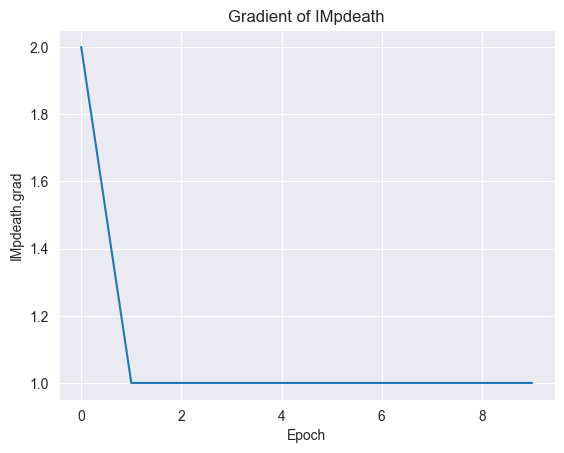

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
plt.plot(grad_values)
plt.xlabel('Epoch')
plt.ylabel('IMpdeath.grad')
plt.title('Gradient of IMpdeath')
plt.show()